# MSDS 451 Programming Assignment 1: MCD Daily Return Direction
Predict whether McDonald's (MCD) closes up (1) or flat/down (0) versus the prior day, using only prior-day information.

1. Import libraries
2. Get data
3. Feature engineering
4. Exploratory data analysis
5. Define `X` and `y`
6. Feature selection (AIC)
7. Select model features
8. Time-series CV splits
9. Baseline XGBoost
10. Grid search tuning
11. Final model evaluation

## Step 1: Import Libraries

In [25]:
import os
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter(action='ignore', category=FutureWarning)

# Import Python Packages for data manipulation, data pipelines, and databases
import numpy as np
import pyarrow # foundation for polars
import polars as pl # DataFrame work superior to Pandas

# Plotting
import matplotlib.pyplot as plt
# Display static plots directly in the notebook output 
%matplotlib inline
# create stylized visualizations, including heat maps
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (GridSearchCV, 
                                    TimeSeriesSplit)
from sklearn.model_selection import cross_validate

# utilized in all possible subsets classification work
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

# alternative classical classifiers for model comparison
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# metrics in xgboost tuning and final model evaluation
from sklearn.metrics import (accuracy_score,
                             classification_report, 
                             roc_curve, 
                             roc_auc_score,
                             RocCurveDisplay,
                             ConfusionMatrixDisplay,
                             confusion_matrix,
                             precision_score,
                             recall_score,
                             f1_score
                            )

# XGBoost Package... more complete than SciKit-Learn boosting methods
import xgboost as xgb
from xgboost import XGBRegressor, XGBClassifier, plot_importance

import yfinance as yf  # used to obtain the price series

import warnings
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore') 

## Step 2: Get Data
Download daily MCD prices (2000 to present) from Yahoo Finance and save to CSV.

In [26]:
start_date = '2000-01-01'
end_date = '2026-09-29'
startfile = "451_pa1_historical_data_"
symbol = 'MCD'

ticker = yf.Ticker(symbol)
historical_data = ticker.history(start = start_date, end = end_date)
print(historical_data.head())
historical_data.to_csv(startfile + symbol + ".csv")

                                Open       High        Low      Close  \
Date                                                                    
2000-01-03 00:00:00-05:00  20.799598  20.864698  20.278794  20.636847   
2000-01-04 00:00:00-05:00  20.474092  20.604293  19.985838  20.213690   
2000-01-05 00:00:00-05:00  20.213699  21.027455  20.213699  20.539202   
2000-01-06 00:00:00-05:00  20.376440  20.506640  20.148588  20.246239   
2000-01-07 00:00:00-05:00  20.311350  20.832154  20.246250  20.767054   

                            Volume  Dividends  Stock Splits  
Date                                                         
2000-01-03 00:00:00-05:00  4520600        0.0           0.0  
2000-01-04 00:00:00-05:00  4216500        0.0           0.0  
2000-01-05 00:00:00-05:00  5231600        0.0           0.0  
2000-01-06 00:00:00-05:00  4809400        0.0           0.0  
2000-01-07 00:00:00-05:00  5124700        0.0           0.0  


In [27]:
# check that the file is in the working directory
!ls 

451_pa1_historical_data_MCD.csv Assignment1
451_pa1_kshaunishSoni.ipynb     mcd-with-computed-features.csv


## Step 3: Feature Engineering
All features use prior-day data to avoid leakage.

| Features | Description |
|---|---|
| `CloseLag1-3` | Lagged closing price |
| `HMLLag1-3` | Lagged high minus low |
| `OMCLag1-3` | Lagged open minus close |
| `VolumeLag1-3` | Lagged volume |
| `CloseEMA2/4/8` | EMAs of `CloseLag1` |

**Target:** 1 if the daily log return is positive, else 0.

In [28]:
mcd = pl.read_csv("451_pa1_historical_data_MCD.csv", try_parse_dates=True)

# check the original schema
print(mcd.schema)

# drop useless columns Dividends and StockSplits
mcd = mcd.drop(['Dividends', 'Stock Splits'])

# create lag price features
mcd = mcd.with_columns((pl.col('Close')).shift().alias('CloseLag1'))
mcd = mcd.with_columns((pl.col('CloseLag1')).shift().alias('CloseLag2'))
mcd = mcd.with_columns((pl.col('CloseLag2')).shift().alias('CloseLag3'))

# create high-minus-low (HML) for day and its lags
mcd = mcd.with_columns((pl.col('High') - pl.col('Low')).alias('HML'))
mcd = mcd.with_columns((pl.col('HML')).shift().alias('HMLLag1'))
mcd = mcd.with_columns((pl.col('HMLLag1')).shift().alias('HMLLag2'))
mcd = mcd.with_columns((pl.col('HMLLag2')).shift().alias('HMLLag3'))

# create a net change for the day as the open minus closing price OMC
# also create the corresponding lag metrics
mcd = mcd.with_columns((pl.col('Open') - pl.col('Close')).alias('OMC'))
mcd = mcd.with_columns((pl.col('OMC')).shift().alias('OMCLag1'))
mcd = mcd.with_columns((pl.col('OMCLag1')).shift().alias('OMCLag2'))
mcd = mcd.with_columns((pl.col('OMCLag2')).shift().alias('OMCLag3'))

# create volume lag metrics
mcd = mcd.with_columns((pl.col('Volume')).shift().alias('VolumeLag1'))
mcd = mcd.with_columns((pl.col('VolumeLag1')).shift().alias('VolumeLag2'))
mcd = mcd.with_columns((pl.col('VolumeLag2')).shift().alias('VolumeLag3'))

# compute 10-day exponential moving averages of closing prices
# compute acround CloseLag1 to avoid any "leakage" in explanatory variable set
# note also the 10-day buffer between train and test in time-series cross-validation
mcd = mcd.with_columns((pl.col('CloseLag1').ewm_mean(half_life=1,ignore_nulls=True)).alias('CloseEMA2'))
mcd = mcd.with_columns((pl.col('CloseLag1').ewm_mean(half_life=2,ignore_nulls=True)).alias('CloseEMA4'))
mcd = mcd.with_columns((pl.col('CloseLag1').ewm_mean(half_life=4,ignore_nulls=True)).alias('CloseEMA8'))

# log daily returns
mcd = mcd.with_columns(np.log(pl.col('Close')/pl.col('CloseLag1')).alias('LogReturn'))

# set volume features to Float64 for subsequent use in Numpy arrays
mcd = mcd.with_columns(
    pl.col('Volume').cast(pl.Float64).round(0),
    pl.col('VolumeLag1').cast(pl.Float64).round(0),
    pl.col('VolumeLag2').cast(pl.Float64).round(0),
    pl.col('VolumeLag3').cast(pl.Float64).round(0),
    )

# round other features to three decimal places for reporting and subsequent analytics
mcd = mcd.with_columns(
    pl.col('Open').round(3),
    pl.col('High').round(3),    
    pl.col('Low').round(3),
    pl.col('Close').round(3),      
    pl.col('CloseLag1').round(3),
    pl.col('CloseLag2').round(3),  
    pl.col('CloseLag3').round(3),
    pl.col('HML').round(3),  
    pl.col('HMLLag1').round(3),
    pl.col('HMLLag2').round(3),  
    pl.col('HMLLag3').round(3),
    pl.col('OMC').round(3),  
    pl.col('OMCLag1').round(3),
    pl.col('OMCLag2').round(3),  
    pl.col('OMCLag3').round(3), 
    pl.col('CloseEMA2').round(3),
    pl.col('CloseEMA4').round(3), 
    pl.col('CloseEMA8').round(3))
    
# define binary target/response 1 = market price up since previous day, 0 = even or down 
mcd = mcd.with_columns(pl.when(pl.col('LogReturn')>0.0).then(pl.lit(1)).otherwise(pl.lit(0)).alias('Target'))

print(mcd.schema)

# save to external comma-delimited text file for checking calculations in Excel
mcd.write_csv("mcd-with-computed-features.csv")

Schema({'Date': Datetime(time_unit='us', time_zone='UTC'), 'Open': Float64, 'High': Float64, 'Low': Float64, 'Close': Float64, 'Volume': Int64, 'Dividends': Float64, 'Stock Splits': Float64})
Schema({'Date': Datetime(time_unit='us', time_zone='UTC'), 'Open': Float64, 'High': Float64, 'Low': Float64, 'Close': Float64, 'Volume': Float64, 'CloseLag1': Float64, 'CloseLag2': Float64, 'CloseLag3': Float64, 'HML': Float64, 'HMLLag1': Float64, 'HMLLag2': Float64, 'HMLLag3': Float64, 'OMC': Float64, 'OMCLag1': Float64, 'OMCLag2': Float64, 'OMCLag3': Float64, 'VolumeLag1': Float64, 'VolumeLag2': Float64, 'VolumeLag3': Float64, 'CloseEMA2': Float64, 'CloseEMA4': Float64, 'CloseEMA8': Float64, 'LogReturn': Float64, 'Target': Int32})


## Step 4: Exploratory Data Analysis
Drop null rows created by lagging and review descriptive statistics.

In [29]:
# Drop the rows with null values such as the initial lag rows
mcd = mcd.drop_nulls()

# Descriptive statistics
mcdStatistics = mcd.drop('Date').describe()

print(mcdStatistics.columns)

mcdStatisticsToPrint = mcdStatistics.transpose(include_header=True).drop(['column_1', 'column_5', 'column_7'])

print(mcdStatisticsToPrint.schema)

with pl.Config(
    tbl_rows = 60,
    tbl_width_chars = 200,
    tbl_cols = -1,
    float_precision = 3,
    tbl_hide_dataframe_shape = True,
    tbl_hide_column_data_types = True):
    print(mcdStatisticsToPrint)

['statistic', 'Open', 'High', 'Low', 'Close', 'Volume', 'CloseLag1', 'CloseLag2', 'CloseLag3', 'HML', 'HMLLag1', 'HMLLag2', 'HMLLag3', 'OMC', 'OMCLag1', 'OMCLag2', 'OMCLag3', 'VolumeLag1', 'VolumeLag2', 'VolumeLag3', 'CloseEMA2', 'CloseEMA4', 'CloseEMA8', 'LogReturn', 'Target']
Schema({'column': String, 'column_0': String, 'column_2': String, 'column_3': String, 'column_4': String, 'column_6': String, 'column_8': String})
┌────────────┬──────────┬─────────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬─────────────────────┐
│ column     ┆ column_0 ┆ column_2                ┆ column_3             ┆ column_4             ┆ column_6              ┆ column_8            │
╞════════════╪══════════╪═════════════════════════╪══════════════════════╪══════════════════════╪═══════════════════════╪═════════════════════╡
│ statistic  ┆ count    ┆ mean                    ┆ std                  ┆ min                  ┆ 50%                   ┆ max                 

## Step 5: Define `X` and `y`
Exclude same-day price columns from `X`; `y` is `Target`. A standardized copy of `X` is used only for the AIC search; models use unscaled features to avoid scaling leakage across CV folds.

In [30]:
# Select Features for the Model, exclude current day price variables ... no "leakage"
# note for moving averages, we have excluded the current day, and provide a 10-day gap
# so these may be included in the set
X = mcd.drop(['Date', 'LogReturn', 'Target', 'Open', 'High', 'Low', 'Close', 'Volume', 'HML', 'OMC'])
X.head()

# Define and examine the target for classification model development
print(mcd['Target'].value_counts())

y = np.array(mcd['Target'])

featureNames = X.columns
print("Feature names correspond to Numpy array columns:",featureNames)

# keep the unscaled features for modeling; Step 7 selects columns from XRaw
XRaw = np.array(X)

# standardized copy used only for the in-sample AIC feature search in Step 6
# (models scale inside each cross-validation fold to avoid leakage)
scaler = StandardScaler()
X = scaler.fit_transform(XRaw)

shape: (2, 2)
┌────────┬───────┐
│ Target ┆ count │
│ ---    ┆ ---   │
│ i32    ┆ u32   │
╞════════╪═══════╡
│ 0      ┆ 3198  │
│ 1      ┆ 3523  │
└────────┴───────┘
Feature names correspond to Numpy array columns: ['CloseLag1', 'CloseLag2', 'CloseLag3', 'HMLLag1', 'HMLLag2', 'HMLLag3', 'OMCLag1', 'OMCLag2', 'OMCLag3', 'VolumeLag1', 'VolumeLag2', 'VolumeLag3', 'CloseEMA2', 'CloseEMA4', 'CloseEMA8']


## Step 6: Feature Selection (AIC)
Fit a logistic regression on every subset of the 15 features and rank by AIC (lower is better). *Slow: ~32,000 fits.*

In [ ]:
# Polars DataFrame for storing results from all possible subsets 
resultsSchema = {"trialNumber": pl.Int64, "features": pl.String, 'aic': pl.Float64} 
resultsDataFrame = pl.DataFrame(schema = resultsSchema) 

def getAIC(X, y): 
    model = LogisticRegression()
    model.fit(X, y)
    # Calculate log-likelihood
    loglik = -log_loss(y, model.predict_proba(X)) * len(y)    
    # Calculate the number of parameters
    k = X.shape[1] + 1    
    # Calculate AIC... smaller is better
    aic = 2 * k -2 * loglik     
    # print(f"AIC: {aic}") # print for initial testing
    return aic

from itertools import chain, combinations

def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(1, len(s)))

trialNumber = 0 # initialize count
for c in powerset(range(X.shape[1])):
    trialNumber = trialNumber + 1
    # print(c)
    thisAIC = getAIC(X[:,c], y)
    thisTrialDataFrame = pl.DataFrame({"trialNumber": trialNumber,
                                       "features": ' '.join(map(str, c)),
                                       "aic": thisAIC},
                                        schema=resultsSchema)          
    resultsDataFrame = pl.concat([resultsDataFrame,thisTrialDataFrame])

# one more set of features... all features
trialNumber = trialNumber + 1
thisAIC = getAIC(X, y)
thisTrialDataFrame = pl.DataFrame({"trialNumber": trialNumber,
                                   "features": "0 1 2 3 4 5 6 7 8 9 10 11 12 13 14",
                                   "aic": thisAIC},
                                    schema=resultsSchema, strict=False)          
resultsDataFrame = pl.concat([resultsDataFrame,thisTrialDataFrame])
print(resultsDataFrame.sort('aic').head(10))

## Step 7: Select Model Features
Five features chosen from the AIC ranking and correlations, keeping one per feature family (two for intraday moves) to limit redundancy:

`OMCLag1`, `HMLLag2`, `OMCLag2`, `VolumeLag2`, `CloseEMA8`

The other price features (`CloseLag1-3`, `CloseEMA2/4`) are >0.999 correlated with `CloseEMA8` and were dropped. All correlations with returns are below 0.035, so the signal is weak.

shape: (6, 6)
┌───────────┬───────────┬───────────┬───────────┬────────────┬───────────┐
│ LogReturn ┆ OMCLag1   ┆ HMLLag2   ┆ OMCLag2   ┆ VolumeLag2 ┆ CloseEMA8 │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---        ┆ ---       │
│ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64        ┆ f64       │
╞═══════════╪═══════════╪═══════════╪═══════════╪════════════╪═══════════╡
│ 1.0       ┆ 0.032725  ┆ -0.013085 ┆ 0.014262  ┆ 0.01832    ┆ -0.009338 │
│ 0.032725  ┆ 1.0       ┆ 0.023961  ┆ -0.047167 ┆ -0.000771  ┆ 0.019587  │
│ -0.013085 ┆ 0.023961  ┆ 1.0       ┆ 0.029194  ┆ -0.150803  ┆ 0.777837  │
│ 0.014262  ┆ -0.047167 ┆ 0.029194  ┆ 1.0       ┆ 0.002042   ┆ 0.017821  │
│ 0.01832   ┆ -0.000771 ┆ -0.150803 ┆ 0.002042  ┆ 1.0        ┆ -0.406993 │
│ -0.009338 ┆ 0.019587  ┆ 0.777837  ┆ 0.017821  ┆ -0.406993  ┆ 1.0       │
└───────────┴───────────┴───────────┴───────────┴────────────┴───────────┘


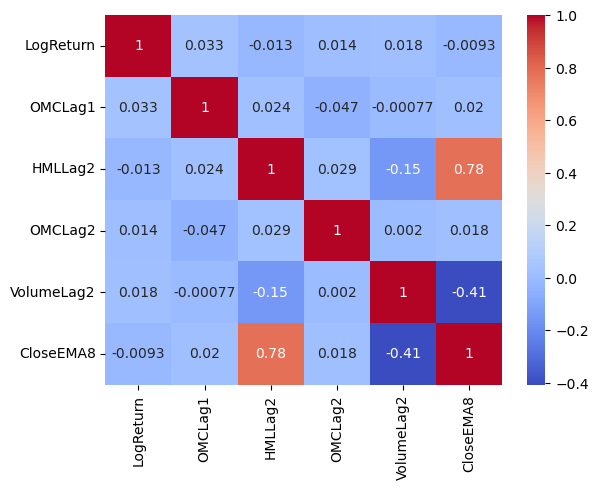

Model input features: ['OMCLag1', 'HMLLag2', 'OMCLag2', 'VolumeLag2', 'CloseEMA8'] X shape: (6721, 5)


In [ ]:
# selected features: one per feature family, guided by the AIC ranking and correlations
selectedFeatures = ['OMCLag1', 'HMLLag2', 'OMCLag2', 'VolumeLag2', 'CloseEMA8']

# examine relationships among the selected features, along with LogReturn
XStudy = mcd.select(['LogReturn'] + selectedFeatures)

# prepare correlation heat map using seaborn
corrMatrix = XStudy.corr()
print(corrMatrix)
sns.heatmap(corrMatrix, cmap='coolwarm', annot=True, xticklabels=XStudy.columns, yticklabels=XStudy.columns)
plt.show()

# restrict the model input matrix to the selected (unscaled) features
# taken from XRaw so this cell can be re-run
selectedIdx = [featureNames.index(f) for f in selectedFeatures]
X = XRaw[:, selectedIdx]
print("Model input features:", selectedFeatures, "X shape:", X.shape)

## Step 8: Time-Series Cross-Validation Splits
Five expanding-window folds, each training on past data and testing on the following block, with a 10-day gap between them.

In [ ]:
# Splitting the datasets into train and test sets
# gap is the number of samples to exclude from 
# the end of each train set and before the next test set.
tscv = TimeSeriesSplit(gap=10, n_splits=5)

all_splits = list(tscv.split(X, y))
train_0, test_0 = all_splits[0]
train_1, test_1 = all_splits[1]
train_2, test_2 = all_splits[2]
train_3, test_3 = all_splits[3]
train_4, test_4 = all_splits[4]

# examine the objects created for cross-validation splits
print("type(all_splits):", type(all_splits), " outer list length", len(all_splits))
print()
print("train_0 has",len(train_0),"with indices from ",min(train_0),"to",max(train_0))
print("test_0 has",len(test_0),"with indices from ",min(test_0),"to",max(test_0))
print()
print("train_1 has",len(train_1),"with indices from ",min(train_1),"to",max(train_1))
print("test_1 has",len(test_1),"with indices from ",min(test_1),"to",max(test_1))
print()
print("train_2 has",len(train_2),"with indices from ",min(train_2),"to",max(train_2))
print("test_2 has",len(test_2),"with indices from ",min(test_2),"to",max(test_2))
print()
print("train_3 has",len(train_3),"with indices from ",min(train_3),"to",max(train_3))
print("test_3 has",len(test_3),"with indices from ",min(test_3),"to",max(test_3))
print()
print("train_4 has",len(train_4),"with indices from ",min(train_4),"to",max(train_4))
print("test_4 has",len(test_4),"with indices from ",min(test_4),"to",max(test_4))

# to see all indices we can uncomment these statements
# print("elements of all_splits list of lists,\n shows index numbers for each the five lists")
# print(all_splits)

type(all_splits): <class 'list'>  outer list length 5

train_0 has 1111 with indices from  0 to 1110
test_0 has 1120 with indices from  1121 to 2240

train_1 has 2231 with indices from  0 to 2230
test_1 has 1120 with indices from  2241 to 3360

train_2 has 3351 with indices from  0 to 3350
test_2 has 1120 with indices from  3361 to 4480

train_3 has 4471 with indices from  0 to 4470
test_3 has 1120 with indices from  4481 to 5600

train_4 has 5591 with indices from  0 to 5590
test_4 has 1120 with indices from  5601 to 6720


## Step 9: Baseline XGBoost
Cross-validated accuracy of an untuned XGBoost model (1,000 trees) as a reference.

In [ ]:
model = XGBClassifier(objective='binary:logistic', n_estimators=1000, random_state=2025)

def evaluate(model, X, y, cv, model_prop=None, model_step=None):
    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=["accuracy"],
        return_estimator=model_prop is not None,
    )
    if model_prop is not None:
        if model_step is not None:
            values = [
                getattr(m[model_step], model_prop) for m in cv_results["estimator"]
            ]
        else:
            values = [getattr(m, model_prop) for m in cv_results["estimator"]]
        print(f"Mean model.{model_prop} = {np.mean(values)}")
    accuracy = -cv_results["test_accuracy"]

    # print used in earlier testing
    # print(
    #    f"Mean Accuracy:     {-accuracy.mean():.3f} +/- {accuracy.std():.3f}\n"
    # )
    return (-accuracy.mean(), accuracy.std())

# print results from evaluate
accuracyMean, accuracyStd = evaluate(model, X, y, cv=tscv, model_prop="n_estimators")
print(
        f"Mean Accuracy:     {accuracyMean:.3f} +/- {accuracyStd:.3f}\n"
     )

Mean model.n_estimators = 1000.0
Mean Accuracy:     0.495 +/- 0.015



## Step 10: Hyperparameter Tuning with GridSearchCV
Exhaustive search over 162 combinations × 5 folds, selected by **accuracy**. ROC AUC and balanced accuracy are also reported.

| Hyperparameter | Values |
|---|---|
| `max_depth` | 3, 5, 7 |
| `min_child_weight` | 1, 5, 10 |
| `subsample` | 0.7, 1.0 |
| `learning_rate` | 0.01, 0.05, 0.1 |
| `n_estimators` | 100, 300, 500 |

In [ ]:
# Grid search over an explicit set of hyperparameter values
# every combination is fit on every time-series fold: 3*3*2*3*3 = 162 combinations x 5 folds = 810 fits
param_grid = {
    'max_depth': [3, 5, 7],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.7, 1.0],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
}
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=2025)

# select on accuracy, and also record ROC AUC and balanced accuracy for each combination
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring={'roc_auc': 'roc_auc', 'balanced_accuracy': 'balanced_accuracy', 'accuracy': 'accuracy'},
    refit='accuracy',
    cv = TimeSeriesSplit(gap=10, n_splits=5),
    n_jobs=-1 # Use all available cores
)

grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best accuracy:", grid_search.best_score_)

# top 10 parameter combinations by mean cross-validated accuracy
gridResults = pl.DataFrame({
    'params': [str(p) for p in grid_search.cv_results_['params']],
    'meanRocAuc': grid_search.cv_results_['mean_test_roc_auc'],
    'stdRocAuc': grid_search.cv_results_['std_test_roc_auc'],
    'meanBalancedAccuracy': grid_search.cv_results_['mean_test_balanced_accuracy'],
    'meanAccuracy': grid_search.cv_results_['mean_test_accuracy'],
})
with pl.Config(float_precision = 3, tbl_width_chars = 200, fmt_str_lengths = 120):
    print(gridResults.sort('meanAccuracy', descending=True).head(10))

Best parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 1.0}
Best ROC AUC: 0.5170184654561936
shape: (10, 5)
┌───────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────┬───────────┬──────────────────────┬──────────────┐
│ params                                                                                                ┆ meanRocAuc ┆ stdRocAuc ┆ meanBalancedAccuracy ┆ meanAccuracy │
│ ---                                                                                                   ┆ ---        ┆ ---       ┆ ---                  ┆ ---          │
│ str                                                                                                   ┆ f64        ┆ f64       ┆ f64                  ┆ f64          │
╞═══════════════════════════════════════════════════════════════════════════════════════════════════════╪════════════╪═══════════╪══════════════════════╪════

## Step 11: Final Model Evaluation
Fit XGBoost on the full dataset with the grid-search best hyperparameters and review the ROC curve, confusion matrix and classification report.

*These results are in-sample and overstate performance; use the cross-validated scores from Steps 9–10 as the out-of-sample estimate.*

Confusion Matrix
[[2583  615]
 [ 445 3078]]


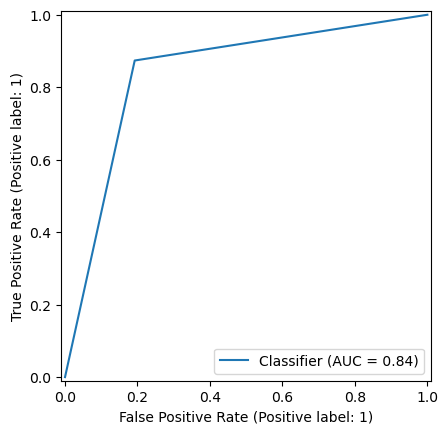

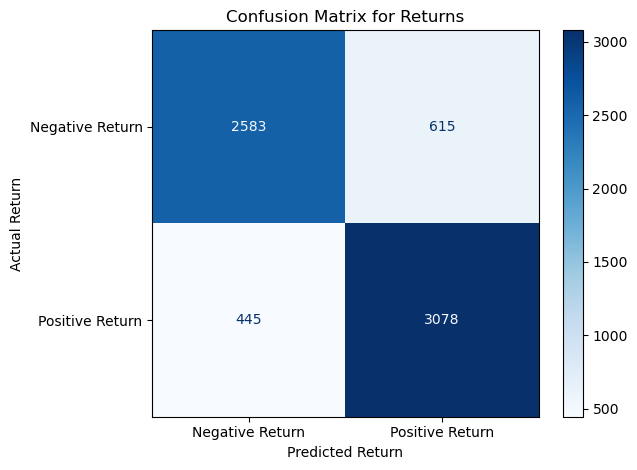

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      3198
           1       0.83      0.87      0.85      3523

   micro avg       0.84      0.84      0.84      6721
   macro avg       0.84      0.84      0.84      6721
weighted avg       0.84      0.84      0.84      6721



In [ ]:
# final model evaluation using the hyperparameters selected by grid search
finalModel = XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=2025,
                          **grid_search.best_params_)
print("Final model parameters:", grid_search.best_params_)

finalModel.fit(X, y)
ypred = finalModel.predict(X)
RocCurveDisplay.from_predictions(y, ypred)
                    

print("Confusion Matrix")
print(confusion_matrix(y, ypred))
disp = ConfusionMatrixDisplay.from_predictions(y, ypred,
                              display_labels =["Negative Return","Positive Return"],
                                              cmap = plt.cm.Blues)
plt.title("Confusion Matrix for Returns")
plt.xlabel("Predicted Return")
plt.ylabel("Actual Return")
plt.tight_layout()
plt.show()      

print(classification_report(y, ypred, labels = ["0","1"]))                       